In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join("..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


In [2]:
%matplotlib inline
%precision %.4g

import numpy as np
import scipy as scp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd 
import sys
import importlib.util
from pathlib import Path
from tracking_ALPs.scripts.plots.param_space_plotting_utils import calculate_n2g

plt.rcParams["text.usetex"] = True
#add the path to the tracking_ALPs directory
tracking_dir = Path(sys.argv[1])

spec = importlib.util.spec_from_file_location(
    "Analyze_madgraph_output",
    str(tracking_dir / "Analyze_madgraph_output.py"),
)

In [3]:
from pathlib import Path
EC_DIR = next(
    p / 'existing_constraints'
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'existing_constraints').is_dir()
)

# Parameters and constants

In [4]:
l_ATLAS_run2_1 = 37 #fb^-1
l_ATLAS_run2 = 139 #fb^-1
l_ATLAS_run3 = 300 #fb^-1
l_ATLAS_HL = 3 #ab^-1
l_CMS_run3 = 312  # fb^-1
l_CMS_HL = 3 #ab^-1
alpha_em = 1/137
sw2 = 0.223
cw2 = 1 - sw2
l_CMS_HL_one_year = 250 #fb^-1

# Conservative parameter choice

In [5]:
ma_list_cms = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.06, 0.07, 0.08, 0.09, 0.1,
    0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
    2.0, 5.0, 10.0,
]
ma_list_cms_run3_extra_masses = [20, 30, 40, 50, 60, 70, 80, 100]
ma_list_cms_run3 = np.concatenate([ma_list_cms, ma_list_cms_run3_extra_masses])
ma_list_atlas =[
    '0_01249609GeV', '0_01561523GeV', '0_01951293GeV', '0_02438354GeV', '0_0304699GeV',
    '0_03807546GeV', '0_04757944GeV', '0_05945571GeV', '0_0742964GeV', '0_09284145GeV',
    '0_11601553GeV', '0_14497407GeV', '0_18116092GeV', '0_22638034GeV', '0_28288694GeV',
    '0_35349811GeV', '0_44173447GeV', '0_55199543GeV', '0_68977854GeV', '0_86195357GeV',
    '1_07710506GeV', '1_34596032GeV', '1_68192432GeV', '2_10174801GeV', '2_62636353GeV',
    '3_28192787GeV', '4_10112707GeV', '5_12480588GeV', '6_40400427GeV', '8_00250228GeV',
]

In [6]:
temp = pd.read_csv('../results/cms/params_cms_phase2.csv', index_col=0, header=None)
params_cms_phase2 = temp.values[1:].astype(float)
params_cms_phase2

array([[0.0000000e+00],
       [3.0000000e-05],
       [4.0000000e-04],
       [1.0000000e-01],
       [2.4607316e-02]])

In [7]:
#Number of events simulated
n_a = 40000
#List of axion masses simulated, modify accordingly if using a different grid
def ma_to_name(ma):
    """Convert an ALP mass (GeV, float) to the filename stub used in data/."""
    return f"{ma:.4f}GeV".replace('.', 'p')
ma_name_list = np.array([ma_to_name(x) for x in ma_list_cms])
#add a prefix to each element in ma_name_list
#ma_name_list = np.array(['merged_ma_' + x for x in ma_name_list])

In [8]:
ma_name_list

array(['0p0100GeV', '0p0200GeV', '0p0300GeV', '0p0400GeV', '0p0500GeV',
       '0p0600GeV', '0p0700GeV', '0p0800GeV', '0p0900GeV', '0p1000GeV',
       '0p2000GeV', '0p3000GeV', '0p4000GeV', '0p5000GeV', '0p6000GeV',
       '0p7000GeV', '0p8000GeV', '0p9000GeV', '1p0000GeV', '2p0000GeV',
       '5p0000GeV', '10p0000GeV'], dtype='<U10')

In [9]:
#Cross sections for the masses simulated in fb
xsec_gagg1e2_list = 180*np.ones(56)


In [11]:

### ATLAS ###
temp = pd.read_csv('../results/atlas/params_atlas.csv', index_col=0, header=None)
params_atlas = temp.values[1:].astype(float)

#Results of the simulation
temp = pd.read_csv('../results/atlas/results_vbf_isolated_atlas.csv', index_col=0, header=None)
gagg_list_atlas = temp.values[0]

#Sort the array by hand because the runs finished in a different order than were submitted
temp_sorted = temp.reindex(np.append(['g_agg'], ma_list_atlas))

#Remove results with few events which are due to some noise/bug in the simulation
temp_sorted[temp_sorted<37] = 0.
#Calculate fraction of events that are isolated
n2g_na_atlas = temp_sorted.values[1:]/1.0E6

### CMS Run 3 ###
temp = pd.read_csv('../results/cms/results_vbf_run3_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3 = temp.values[0]
n2g_na_cms_run3 = temp.values[1:]/n_a
n2g_na_cms_run3


### CMS Phase 2 ###
temp = pd.read_csv('../results/cms/results_vbf_phase2_isolated.csv', index_col=0, header=None)
gagg_list_cms_phase2 = temp.values[0]
#Calculate fraction of events that are isolated
n2g_na_cms_phase2 = temp.values[1:]/n_a

###CMS Run 3, only eta cut 
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/run3/mask_eta/results_vbf_run3_mask_eta_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3_eta = temp.values[0]
n2g_na_cms_run3_eta = temp.values[1:]/n_a

##CMS Run 3, only eta and vbf cuts
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/run3/mask_vbf_mask_eta/results_vbf_run3_mask_vbf_mask_eta_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3_vbf_eta = temp.values[0]
n2g_na_cms_run3_vbf_eta = temp.values[1:]/n_a
 
##CMS Run 3, only vbf cuts ### 
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/run3/mask_vbf/results_vbf_run3_mask_vbf_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3_vbf = temp.values[0]
n2g_na_cms_run3_vbf = temp.values[1:]/n_a


## CMS Run 3, mask eta, vbf and merge cuts ### 
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/run3/mask_vbf_mask_eta_mask_merge/results_vbf_run3_mask_vbf_mask_eta_mask_merge_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3_vbf_eta_merge = temp.values[0]
n2g_na_cms_run3_vbf_eta_merge = temp.values[1:]/n_a

###CMS Run 3, mask, eta, vbf, merge and tracker cuts ### 
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/run3/mask_vbf_mask_eta_mask_tracker_mask_merge/results_vbf_run3_mask_vbf_mask_eta_mask_tracker_mask_merge_accepted.csv', index_col=0, header=None)
gagg_list_cms_run3_vbf_eta_merge_tracker = temp.values[0]
n2g_na_cms_run3_vbf_eta_merge_tracker = temp.values[1:]/n_a


### CMS Phase2, eta range 1.4-3 ### 
temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/mask_eta/results_vbf_run3_mask_eta_eta_range_1p4_3_accepted.csv', index_col=0, header=None)
gagg_list_cms_phase2_eta_range_1p4_3 = temp.values[0]
n2g_na_cms_phase2_eta_range_1p4_3 = temp.values[1:]/n_a

###CMS Phase2, eta range 1.4-3, vbf ### 

temp = pd.read_csv('/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/mask_vbf_mask_eta/results_vbf_run3_mask_vbf_mask_eta_eta_range_1p4_3_vbf_accepted.csv', index_col=0, header=None)
gagg_list_cms_phase2_eta_range_1p4_3_vbf = temp.values[0]
n2g_na_cms_phase2_eta_range_1p4_3_vbf = temp.values[1:]/n_a






In [10]:
### config 1 ### 
temp = pd.read_csv("/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/0514/mask_vbf_mask_eta_mask_tracker_mask_merge/results_vbf_run3_mask_vbf_mask_eta_mask_tracker_mask_merge_eta_range_1p4_3_vbf_tracker_merge_accepted.csv", index_col=0, header=None)
config_1 = temp.values[0]
gagg_list = config_1
n2g_na_config_1 = temp.values[1:]/n_a

### config 2 ### 
temp = pd.read_csv("/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/0514/mask_eta_mask_tracker_mask_merge/results_vbf_run3_mask_eta_mask_tracker_mask_merge_eta_range_1p4_3_tracker_merge_accepted.csv", index_col=0, header=None)
config_2 = temp.values[0]
n2g_na_config_2 = temp.values[1:]/n_a

### config 3 ### 
temp = pd.read_csv("/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/0514/mask_eta_mask_tracker_mask_merge/results_vbf_run3_mask_eta_mask_tracker_mask_merge_eta_range_0_2p5_tracker_merge_accepted.csv", index_col=0, header=None)
config_3 = temp.values[0]
n2g_na_config_3 = temp.values[1:]/n_a

### config 4 ### 
temp = pd.read_csv("/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/0514/phase2/results_vbf_phase2_mask_eta_mask_merge_mask_tracker_eta_range_0_2p5_tracker_merge_displacement_5mmmask_etamask_mergemask_tracker_displaced.csv", index_col=0, header=None)
config_4 = temp.values[0]
n2g_na_config_4 = temp.values[1:]/n_a
n2g_na_config_6 = temp.values[1:]/n_a

##Config 5 ( run 3 data parking) (CMS Run 3, mask eta 0 -2.5, vbf, tracker and merge  0.3 cuts ) ### 
temp = pd.read_csv("/home/export/sdurgut/scratch/alps/tracking_ALPs/results/cms/extra_masses/0514/mask_vbf_mask_eta_mask_tracker_mask_merge/results_vbf_run3_mask_vbf_mask_eta_mask_tracker_mask_merge_eta_range_0_2p5_vbf_tracker_merge_accepted.csv", index_col=0, header=None)
config_5 = temp.values[0]
n2g_na_config_5 = temp.values[1:]/n_a


In [11]:
#Calculate the production cross-section
prod_xsec_pp_a_13TeV_list = np.array([xsec_gagg1e2_list * (x/1.0E-2)**2 for x in gagg_list_atlas])
n_a_ATLAS_run2_list = l_ATLAS_run2/1.0E-3 * prod_xsec_pp_a_13TeV_list
n_a_ATLAS_run3_list = l_ATLAS_run3/1.0E-3 * prod_xsec_pp_a_13TeV_list
n_a_ATLAS_HL_list = l_ATLAS_HL/1.0E-6 * prod_xsec_pp_a_13TeV_list
    
#Cross-section for events that pass the requirements
xsec_2g = np.array([[n2g_na_atlas[i,j] * prod_xsec_pp_a_13TeV_list[j,i] for i in range(len(ma_list_atlas))] for j in range(len(gagg_list_atlas))])

NameError: name 'gagg_list_atlas' is not defined

In [12]:
prod_xsec_pp_a_13TeV_list_cms_run3 = np.array([xsec_gagg1e2_list * (x/1.0E-2)**2 for x in gagg_list])
n_a_CMS_run3_list = l_CMS_run3/1.0E-3 * prod_xsec_pp_a_13TeV_list_cms_run3
n_a_CMS_HL_list = l_CMS_HL/1.0E-6 * prod_xsec_pp_a_13TeV_list_cms_run3
n_a_CMS_HL_one_year_list = l_CMS_HL_one_year/1.0E-3 * prod_xsec_pp_a_13TeV_list_cms_run3
# no need to change unless you are running with different lumi or coupling grid

In [13]:
#Quick function to convert from fraction to total number of events isolated
def n2g (n2g_na, na):
    rslt = n2g_na * na
    return rslt

In [14]:


n2g_run2_atlas = np.array([[n2g(n2g_na_atlas[i, j], n_a_ATLAS_run2_list[j, i]) for i in range(len(ma_list_atlas))] for j in range(len(gagg_list_atlas))])
n2g_run3_atlas = np.array([[n2g(n2g_na_atlas[i, j], n_a_ATLAS_run3_list[j, i]) for i in range(len(ma_list_atlas))] for j in range(len(gagg_list_atlas))])
n2g_HL_atlas = np.array([[n2g(n2g_na_atlas[i, j], n_a_ATLAS_HL_list[j, i]) for i in range(len(ma_list_atlas))] for j in range(len(gagg_list_atlas))])
#n2g_cms_run3 = np.array([[n2g(n2g_na_cms_run3[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3))])
#n2g_cms_phase2 = np.array([[n2g(n2g_na_cms_phase2[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_phase2))])
n2g_cms_run3_eta = np.array([[n2g(n2g_na_cms_run3_eta[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_eta))])
n2g_cms_run3_vbf = np.array([[n2g(n2g_na_cms_run3_vbf[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf))])
n2g_cms_run3_vbf_eta = np.array([[n2g(n2g_na_cms_run3_vbf_eta[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta))])
n2g_cms_run3_vbf_eta_merge = np.array([[n2g(n2g_na_cms_run3_vbf_eta_merge[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta_merge))])
n2g_cms_run3_vbf_eta_merge_tracker = np.array([[n2g(n2g_na_cms_run3_vbf_eta_merge_tracker[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta_merge_tracker))])
n2g_cms_phase2_eta_range_1p4_3 = np.array([[n2g(n2g_na_cms_phase2_eta_range_1p4_3[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_phase2_eta_range_1p4_3))])
n2g_cms_phase2_eta_range_1p4_3_vbf = np.array([[n2g(n2g_na_cms_phase2_eta_range_1p4_3_vbf[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_phase2_eta_range_1p4_3_vbf))])

NameError: name 'gagg_list_atlas' is not defined

In [15]:
n2g_config_1 = np.array([[n2g(n2g_na_config_1[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list))])
n2g_config_2 = np.array([[n2g(n2g_na_config_2[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list))])
n2g_config_3 = np.array([[n2g(n2g_na_config_3[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list))])
n_mass = n2g_na_config_4.shape[0]
n2g_config_4 = np.array([
    [n2g(n2g_na_config_4[i, j], n_a_CMS_HL_list[j, i])
     for i in range(n_mass)]
    for j in range(len(gagg_list))
])
n2g_config_5 = np.array([[n2g(n2g_na_config_5[i, j], n_a_CMS_run3_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list))])
n2g_config_6 = np.array([
    [n2g(n2g_na_config_6[i, j], n_a_CMS_HL_one_year_list[j, i])
     for i in range(n2g_na_config_6.shape[0])]
    for j in range(len(gagg_list))
])

In [16]:
n2g_cms_phase2_eta = np.array([[n2g(n2g_na_cms_run3_eta[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_eta))])
n2g_cms_phase2_eta_vbf = np.array([[n2g(n2g_na_cms_run3_vbf_eta[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta))])
n2g_cms_phase2_eta_vbf_merge = np.array([[n2g(n2g_na_cms_run3_vbf_eta_merge[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta_merge))])
n2g_cms_phase2_eta_vbf_merge_tracker = np.array([[n2g(n2g_na_cms_run3_vbf_eta_merge_tracker[i, j], n_a_CMS_HL_list[j, i]) for i in range(len(ma_list_cms_run3))] for j in range(len(gagg_list_cms_run3_vbf_eta_merge_tracker))])

NameError: name 'gagg_list_cms_run3_eta' is not defined

In [19]:
# Compare with existing bounds

In [17]:
from pathlib import Path
EC_DIR = next(
    p / 'existing_constraints'
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'existing_constraints').is_dir()
)

temp = pd.read_csv(EC_DIR / 'Beam_dump.csv', header=None)
ma_beam_dump = temp.T.values[0]
gag_beam_dump = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'LEP.csv', header=None)
ma_LEP = temp.T.values[0]
gag_LEP = temp.T.values[1]
#LEP Z --> gamma gamma bound with hypercharge coupling
temp = pd.read_csv(EC_DIR / 'LEP_aBB.csv', header=None)
ma_LEP_aBB = temp.T.values[0]*1.0E-9
gag_LEP_aBB = temp.T.values[1]*cw2
#LEP Z --> gamma + inv with hypercharge coupling (1709.00009)
temp = pd.read_csv(EC_DIR / 'Z_gamma_inv_aBB.csv', header=None)
ma_Zginv_aBB = temp.T.values[0]
gag_Zginv_aBB = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'CDF.csv', header=None)
ma_CDF = temp.T.values[0]
gag_CDF = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'PrimEx.csv', header=None)
ma_PrimEx = temp.T.values[0]
gag_PrimEx = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'Belle-II.txt', sep=r'\s+')
ma_BelleII = temp.T.values[0]
gag_BelleII = temp.T.values[2]
temp = pd.read_csv(EC_DIR / 'Belle-II_prospects.csv', header=None)
ma_BelleII_pr = temp.T.values[0]
gag_BelleII_pr = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'PbPb_ATLAS.csv', header=None)
ma_PbPb_ATLAS = temp.T.values[0]
gag_PbPb_ATLAS = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'PbPb_CMS.csv', header=None)
ma_PbPb_CMS = temp.T.values[0]
gag_PbPb_CMS = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'LHC.csv', header=None)
ma_LHC = temp.T.values[0]
gag_LHC = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'NA64.csv', header=None)
ma_NA64 = temp.T.values[0]
gag_NA64 = temp.T.values[1]
temp = pd.read_csv(EC_DIR / 'ALPTraum.csv', header=None)
ma_ALPtraum = temp.T.values[0]
gag_ALPtraum = temp.T.values[1]

In [18]:
from scipy.interpolate import RegularGridInterpolator

def pad_and_smooth(ma_list, gagg_list, n2g, n_fine=80):
    gagg_unique, unique_idx = np.unique(gagg_list, return_index=True)
    n2g = n2g[unique_idx]
    gagg_list = gagg_unique

    ma_pad = np.array([ma_list[0] / 2] + list(ma_list) + [ma_list[-1] * 2])
    z = np.zeros((n2g.shape[0], 1))
    n2g_pad = np.hstack([z, n2g, z])

    g_lo = gagg_list.min() / 3
    g_hi = gagg_list.max() * 3
    gagg_pad = np.concatenate([[g_lo], gagg_list, [g_hi]])
    z_row = np.zeros((1, n2g_pad.shape[1]))
    n2g_pad = np.vstack([z_row, n2g_pad, z_row])

    # Linear interpolation in log-log space — no oscillation
    ma_fine = np.logspace(np.log10(ma_pad[0]), np.log10(ma_pad[-1]), n_fine)
    g_fine = np.logspace(np.log10(gagg_pad[0]), np.log10(gagg_pad[-1]), n_fine)

    interp = RegularGridInterpolator(
        (np.log10(gagg_pad), np.log10(ma_pad)),
        np.log10(n2g_pad + 1e-30),
        method='linear', bounds_error=False, fill_value=-30)

    mg, mm = np.meshgrid(np.log10(g_fine), np.log10(ma_fine), indexing='ij')
    pts = np.column_stack([mg.ravel(), mm.ravel()])
    n2g_fine = 10**interp(pts).reshape(mg.shape)

    MA, GAGG = np.meshgrid(ma_fine, g_fine)
    return MA, GAGG, n2g_fine

In [19]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list_cms_run3_vbf)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
#ax1.contour(MA_cms, GAGG_cms, n2g_cms_run3, levels=[3.], colors=['C0'], linestyles=['-'], linewidths=[2.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_cms_run3_eta, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_cms_run3_vbf, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_cms_run3_vbf_eta, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_cms_run3_vbf_eta_merge, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_cms_run3_vbf_eta_merge_tracker, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])




# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS Run 3 (312 fb$^{-1}$), eta cut')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 (312 fb$^{-1}$), vbf cut')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Run 3 (312 fb$^{-1}$), eta and vbf cuts')
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS Run 3 (312 fb$^{-1}$), eta, vbf and tracker cuts')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'CMS Run 3 (312 fb$^{-1}$), eta, vbf, tracker and merge cuts')


# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'gagg_list_cms_run3_vbf' is not defined

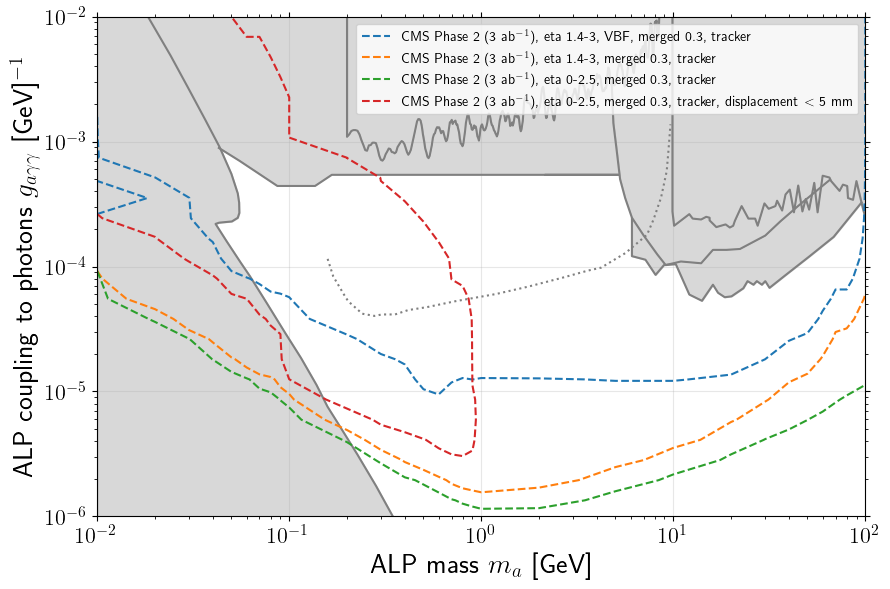

In [20]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
#ax1.contour(MA_cms, GAGG_cms, n2g_cms_run3, levels=[3.], colors=['C0'], linestyles=['-'], linewidths=[2.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, VBF, merged 0.3, tracker')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker, displacement $<$ 5 mm')


# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

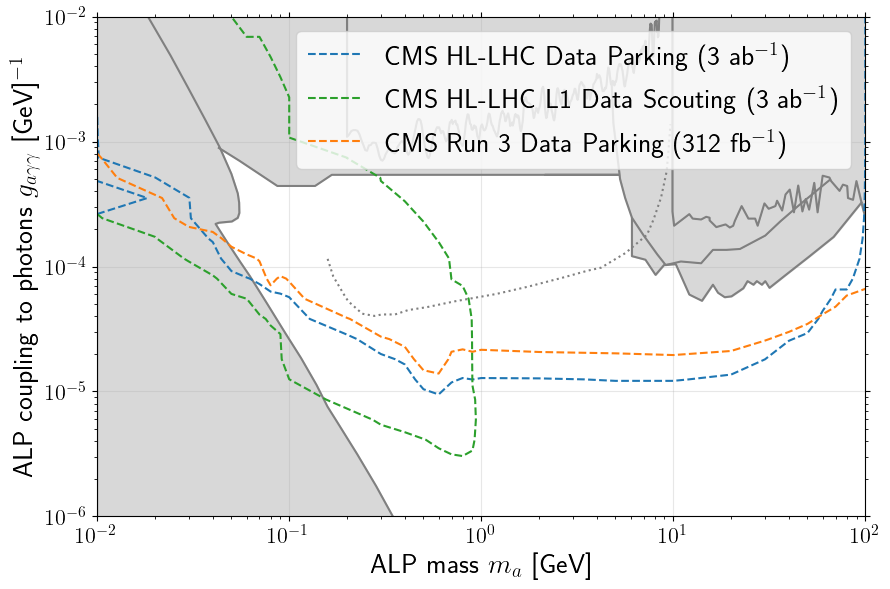

In [24]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_na_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
#ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (2550 fb$^{-1}$)')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

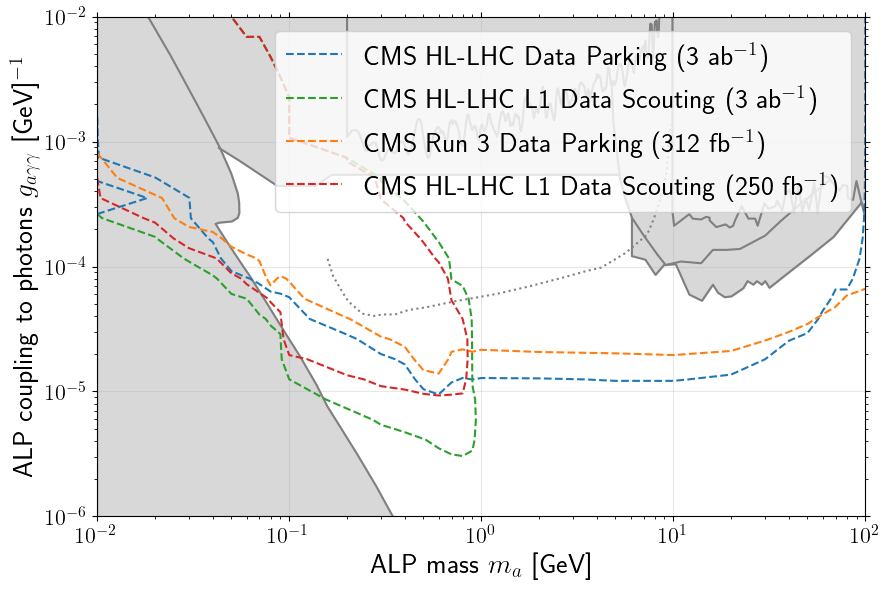

In [25]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
n2g_run3_parking_dR_0p025_0p3 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/results_20260525_182852.csv", lumi=312)

In [27]:
n2g_run3_parking_dR_0p025_0p3.shape

(32, 30)

In [28]:
MA_cms_extra_masses.shape

(32, 30)

In [29]:
n2g_config_6/50

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.30000000e-08, 1.38375000e-06, 1.41750000e-06,
        6.66000000e-07, 5.17500000e-08, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 4.39790771e-07, 4.11417173e-06, 3.24877699e-06,
        6.66779557e-07, 4.72893303e-09, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000

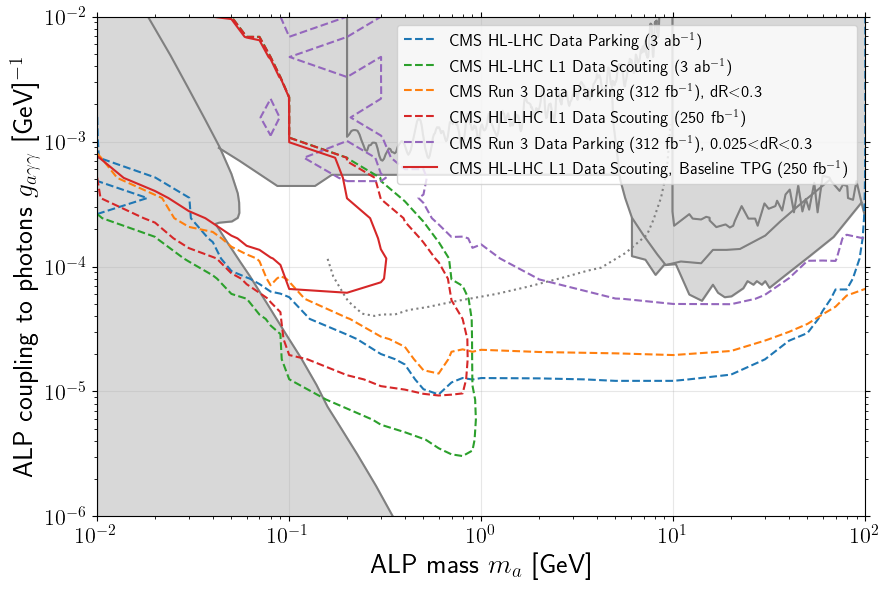

In [30]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
from matplotlib.lines import lineStyles


MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_run3_parking_dR_0p025_0p3, levels=[3.], colors=["C4"], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6/50, levels=[3.], colors=['C3'], linestyles=['-'], linewidths=[1.5])
# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$), dR$<$0.3')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$), 0.025$<$dR$<$0.3')
ax1.plot([], [], c='C3', ls='-', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting, Baseline TPG (250 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
n2g_run3_data_parking_new_analysis= calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_20260525_191635/results_20260525_191635.csv", lumi = 312
)

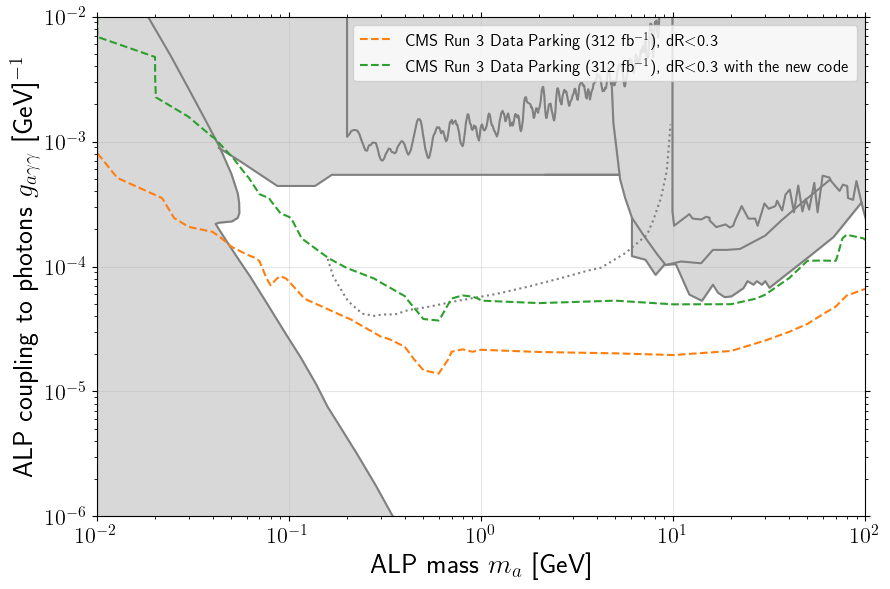

In [32]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
from matplotlib.lines import lineStyles


MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_run3_data_parking_new_analysis, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$), dR$<$0.3')    
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$), dR$<$0.3 with the new code')    


# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
config_1 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config1/results_config1.csv", lumi = 3000)

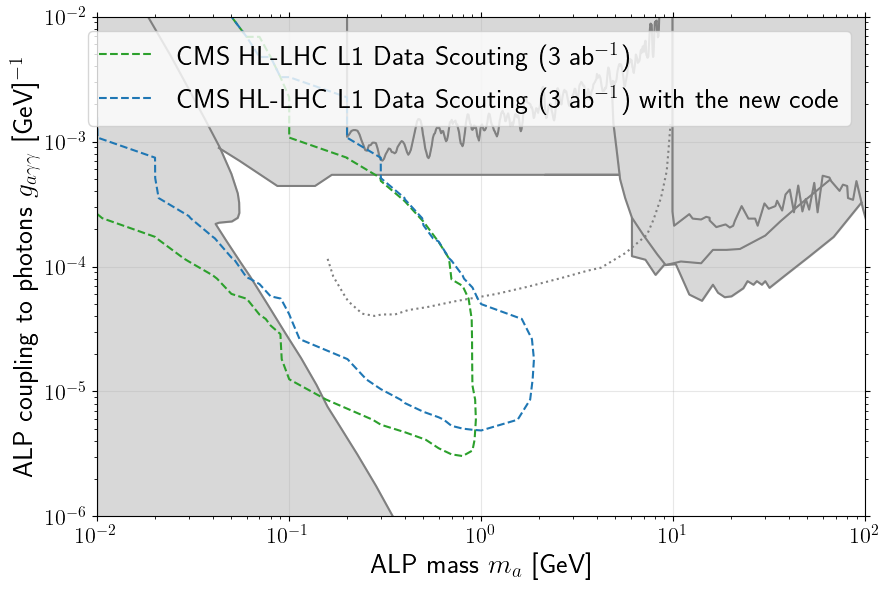

In [34]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
# --- Legend (manual, clean) ---
#ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
#ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$) with the new code')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
config_2 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config2/results_config2.csv", lumi = 3000)

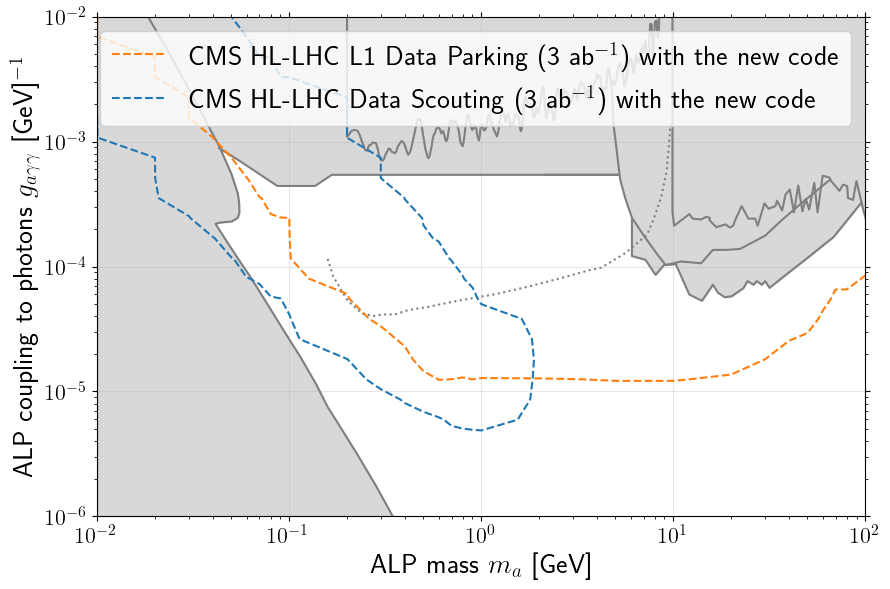

In [36]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
#ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
#ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Parking (3 ab$^{-1}$) with the new code')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Scouting (3 ab$^{-1}$) with the new code')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

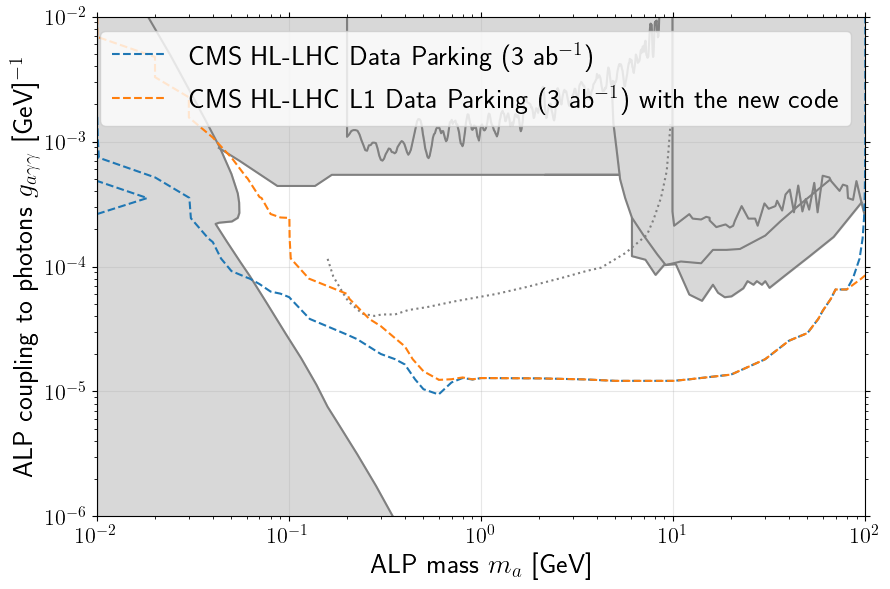

In [37]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
#ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Parking (3 ab$^{-1}$) with the new code')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
config_3 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config3/results_config3.csv", lumi = 312)

In [24]:
config_1_1 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config1/results_config1.csv", lumi = 250)

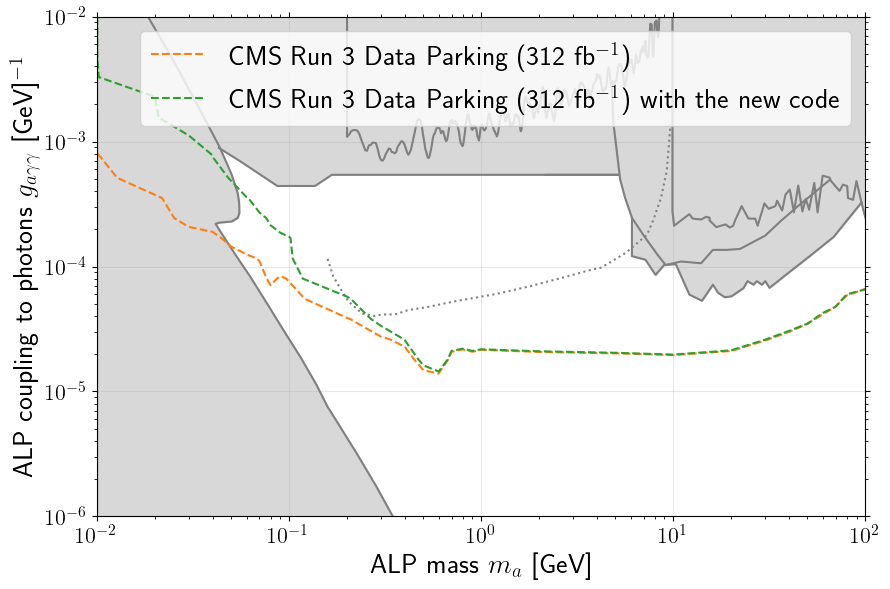

In [40]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_2, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_4, GAGG_cms_config_4, n2g_config_4, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, n2g_config_5, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
#ax1.contour(MA_cms_config_6, GAGG_cms_config_6, n2g_config_6, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_3, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])

# --- Legend (manual, clean) ---
#ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'CMS HL-LHC Data Parking  (3 ab$^{-1}$)')
#ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 1.4-3, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Phase 2 (3 ab$^{-1}$), eta 0-2.5, merged 0.3, tracker')
#ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$)')    
#ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'CMS HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'CMS Run 3 Data Parking (312 fb$^{-1}$) with the new code')    

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', labelsize=16, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
config_1_2 = config_1/50

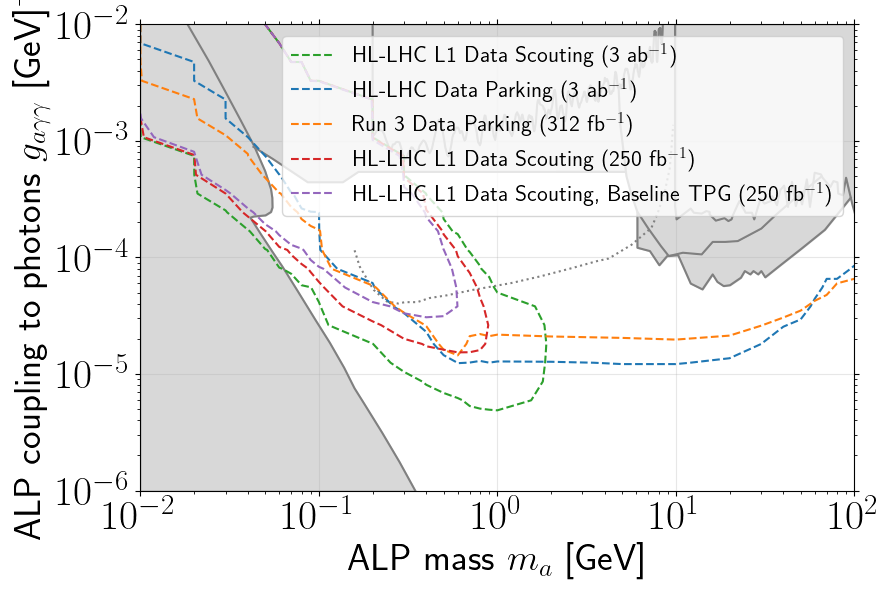

In [42]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_2, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_3, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=16)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
config_4 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config4/results_config4.csv", lumi = 312)

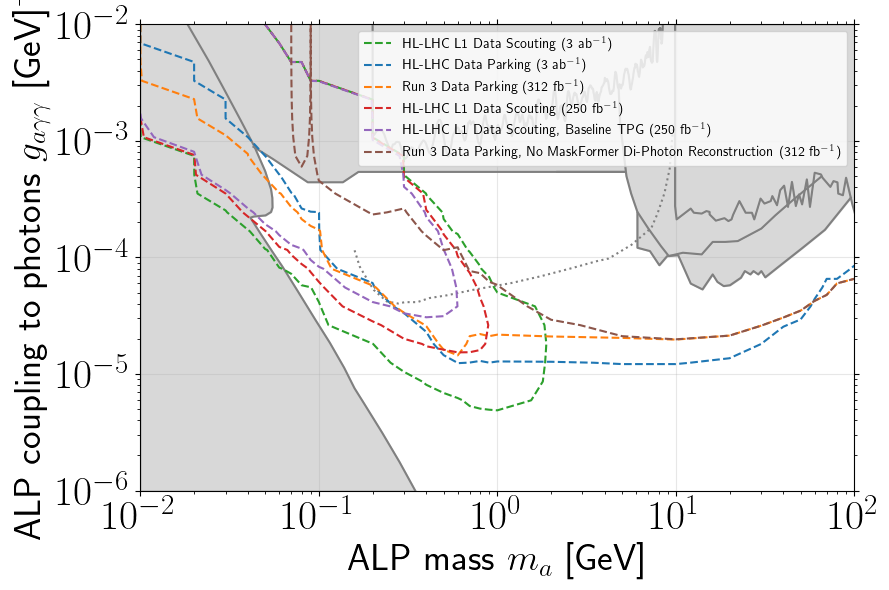

In [44]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_2, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_3, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
config_5 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config5/results_config5.csv", lumi=3000)


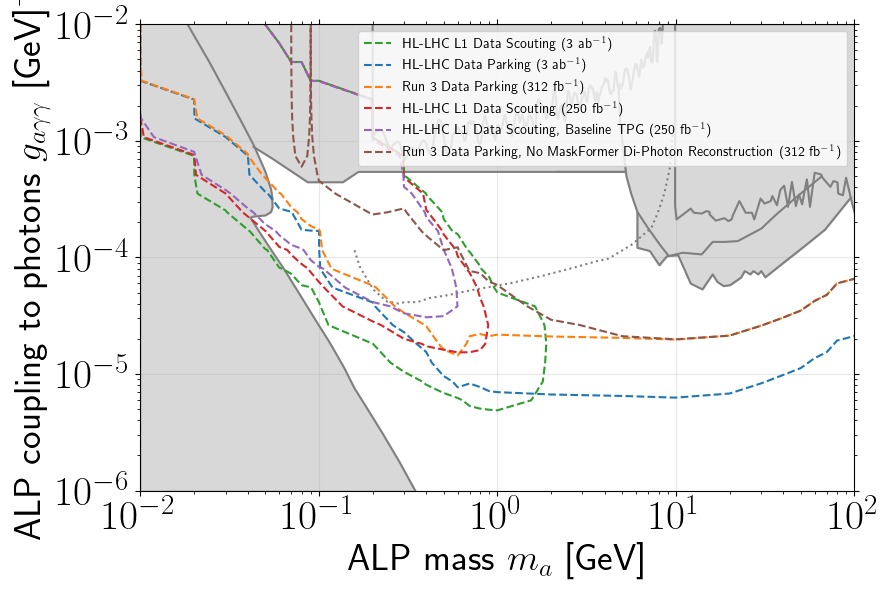

In [46]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_5, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_3, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
config_6 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config6/results_config6.csv", lumi=312)


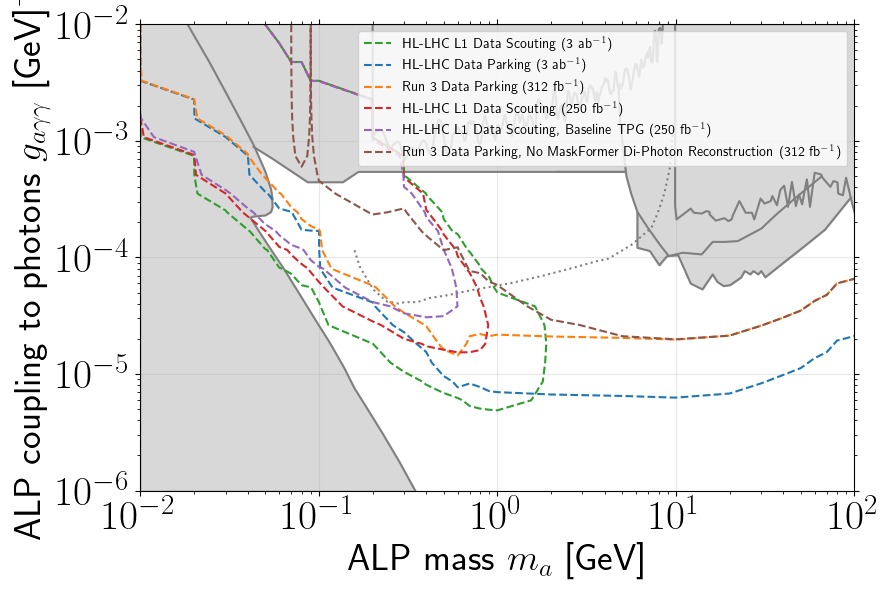

In [48]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_5, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_6, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
config_6_1 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config6/results_config6.csv", lumi=3000)

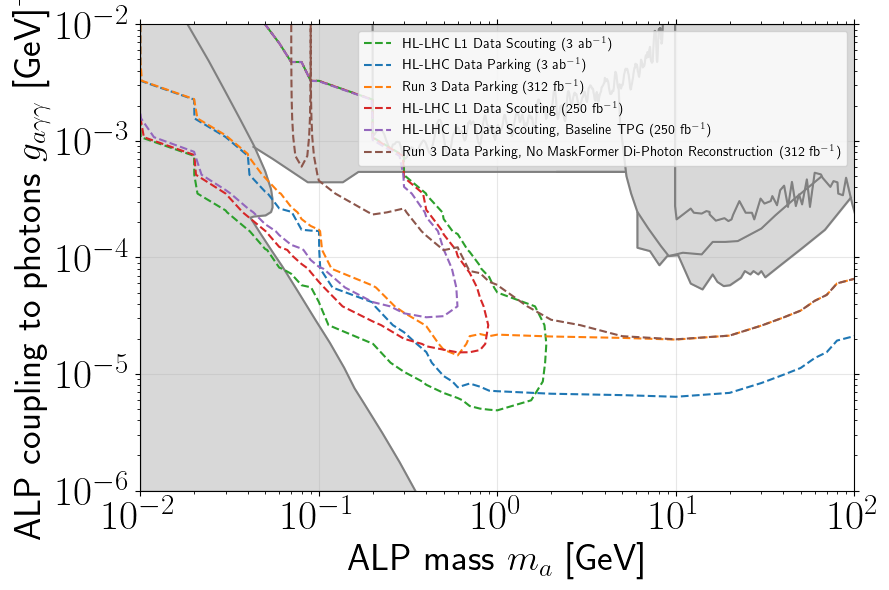

In [50]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_6_1, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_6, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
config_7 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config7/results_config7.csv", lumi=312)
config_8 = calculate_n2g(filename="/home/export/sdurgut/scratch/alps/tracking_ALPs/results/run_config8/results_config8.csv", lumi=3000)

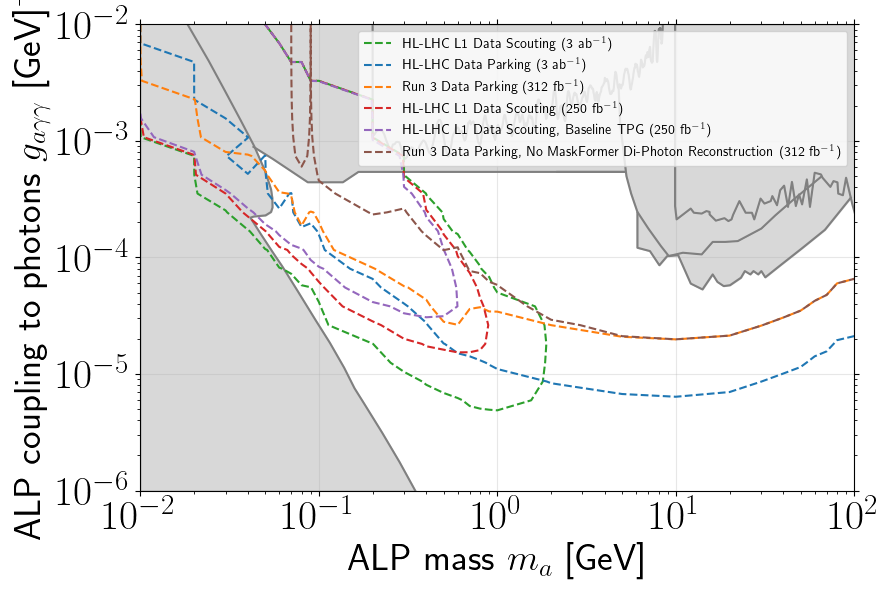

In [52]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_8, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_7, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
#apply manually a noise threshold to the config_4 
config_4_noise = config_4.copy()
config_4_noise[config_4_noise < 4] = 4

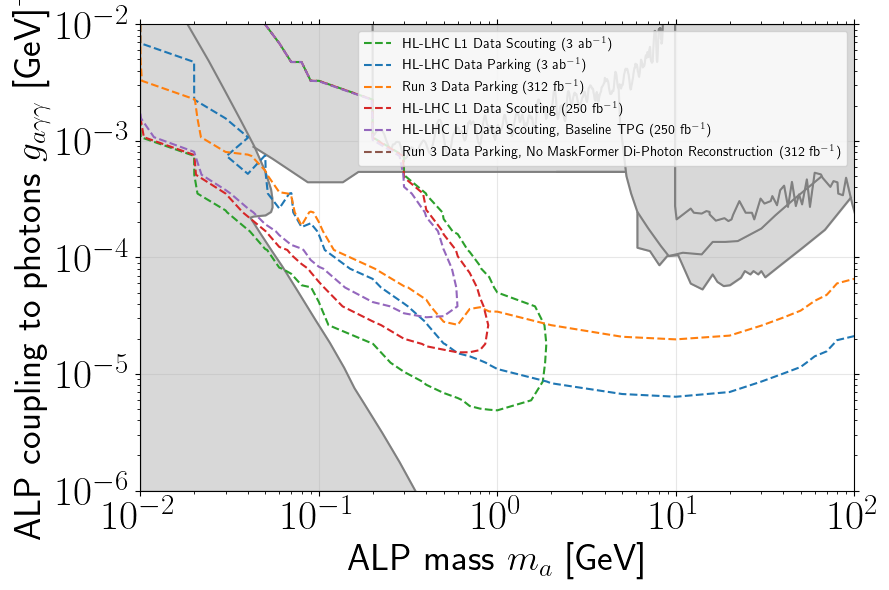

In [32]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_8, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_7, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_2, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[1.5])
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4_noise, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[1.5])



# --- Legend (manual, clean) ---
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (3 ab$^{-1}$)')
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Data Parking  (3 ab$^{-1}$)')
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Data Parking (312 fb$^{-1}$)')    
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting (250 fb$^{-1}$)')
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC L1 Data Scouting, Baseline TPG  (250 fb$^{-1}$)')
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking, No MaskFormer Di-Photon Reconstruction  (312 fb$^{-1}$)')

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=27)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=27)
ax1.tick_params(axis='both', labelsize=30, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('results/cms_vs_atlas_contour.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
config_1_3 = config_1/50 

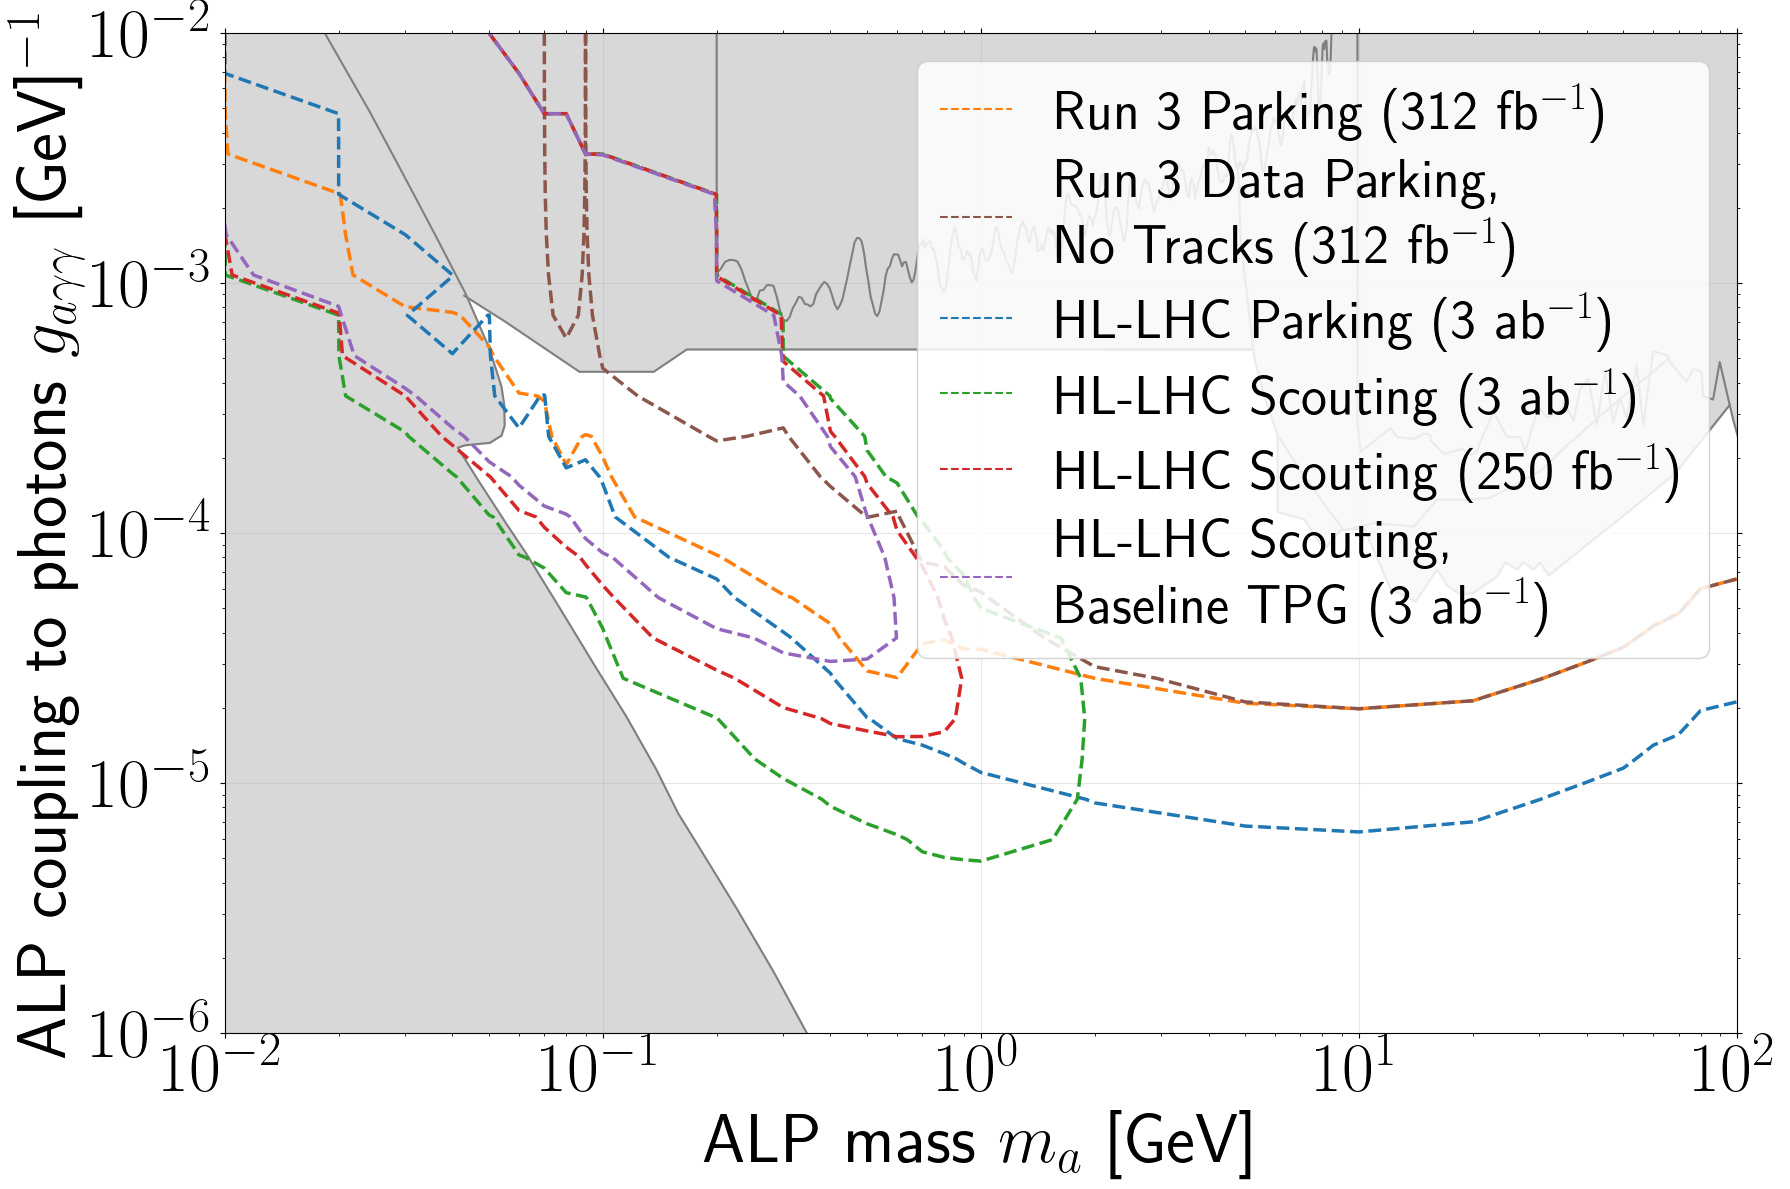

In [ ]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
plt.rcParams['pdf.fonttype'] = 42
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(18, 12))   # was (9, 6) -> add ~3in just for the legend
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_7, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Parking (312 fb$^{-1}$)')    

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Data Parking,' + '\n' + r'No Tracks  (312 fb$^{-1}$)')


ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_8, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Parking  (3 ab$^{-1}$)')

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC Scouting (3 ab$^{-1}$)')

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC Scouting (250 fb$^{-1}$)')

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_3, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC Scouting,' + '\n' + r'Baseline TPG  (3 ab$^{-1}$)')



# --- Legend (manual, clean) ---

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=50)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=50)
ax1.tick_params(axis='both', labelsize=50, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=40, labelspacing=0.3, handlelength=1.3, framealpha=0.85)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#save with high resolution

plt.savefig('/home/export/sdurgut/scratch/alps/tracking_ALPs/plots/final_contour.pdf', dpi=600, bbox_inches='tight')
plt.show()

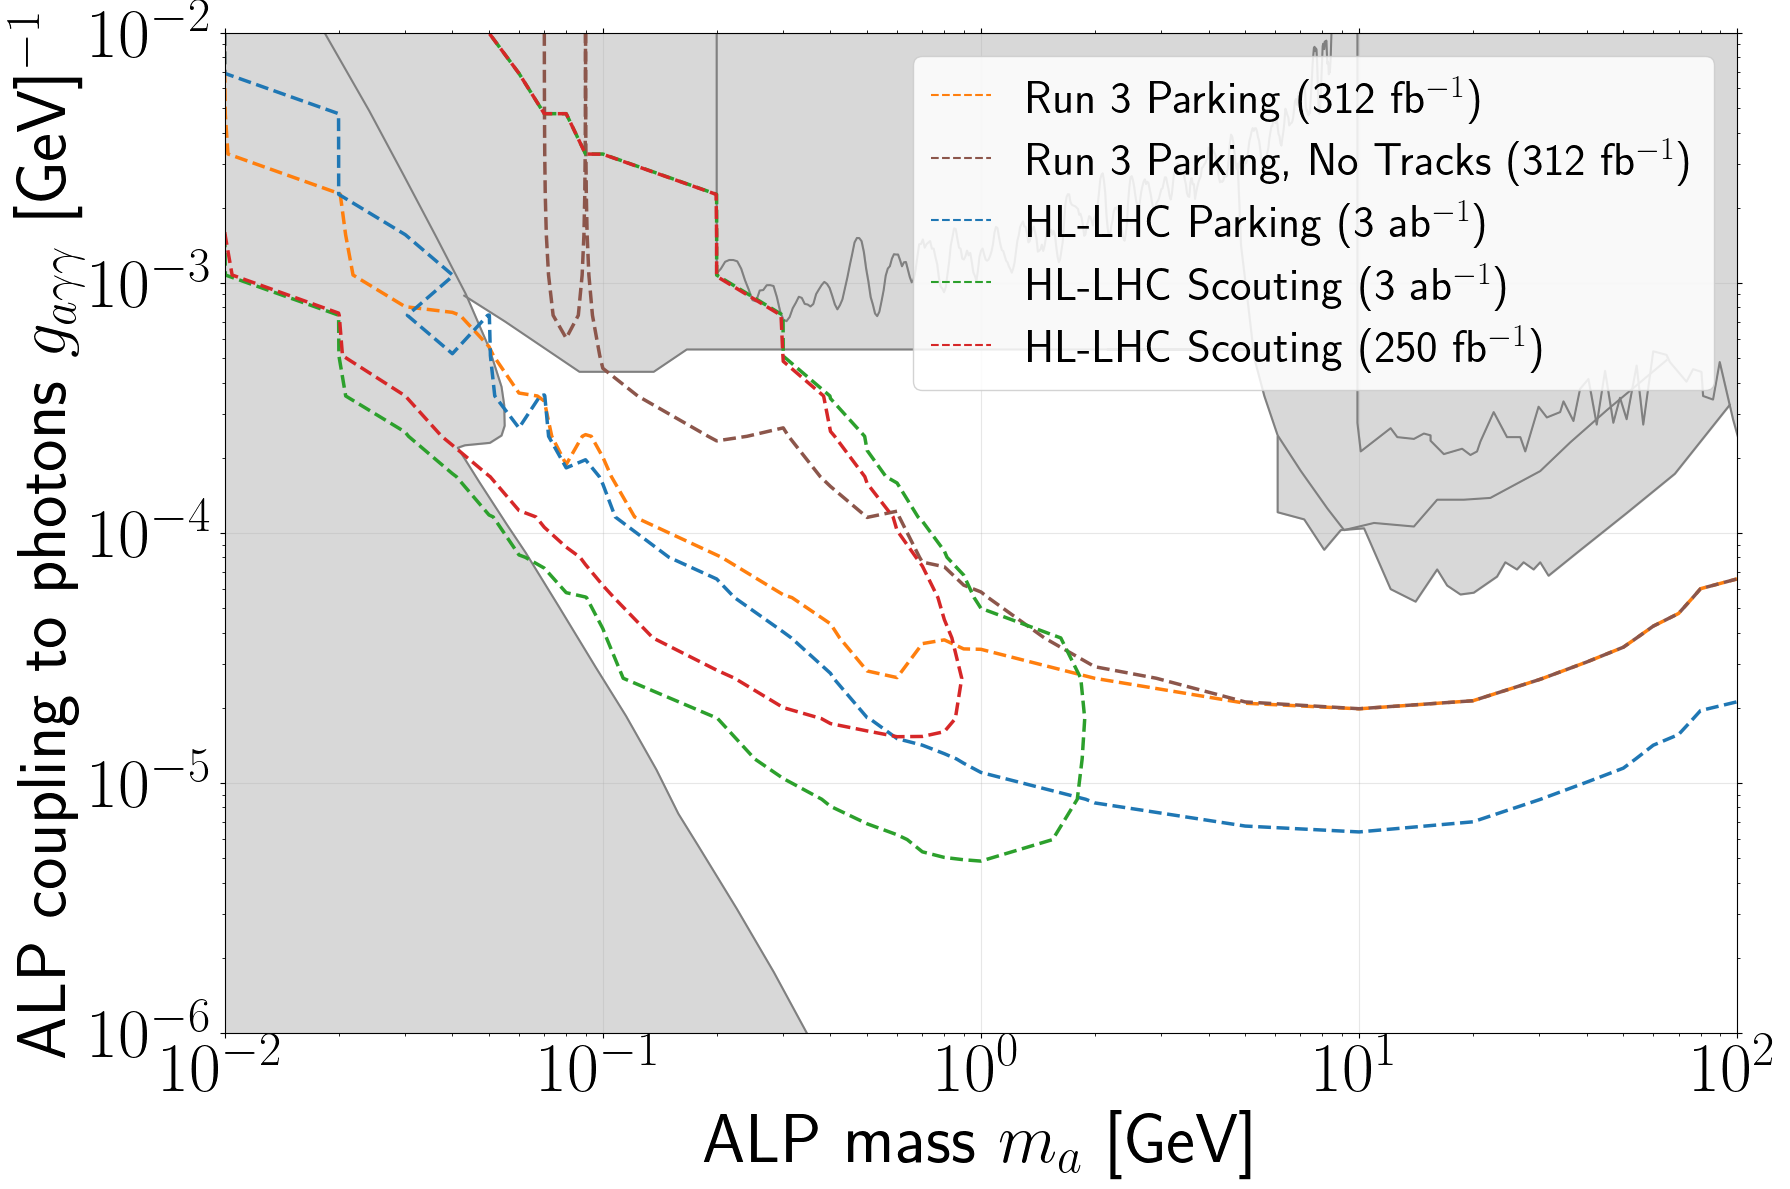

In [37]:
#MA_cms, GAGG_cms = np.meshgrid(ma_list_cms, gagg_list_cms_run3)
plt.rcParams['pdf.fonttype'] = 42
MA_cms_extra_masses, GAGG_cms_extra_masses = np.meshgrid(ma_list_cms_run3, gagg_list)
MA_cms_config_4, GAGG_cms_config_4 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_4.shape[1]],
    gagg_list,
)
MA_cms_config_6, GAGG_cms_config_6 = np.meshgrid(
    ma_list_cms_run3[: n2g_config_6.shape[1]],
    gagg_list,
)
#MA_phase2, GAGG_phase2 = np.meshgrid(ma_list_cms_run3_extra_masses, gagg_list_cms_phase2_extra_masses_dR_0p025)

fig = plt.figure(figsize=(18, 12))   # was (9, 6) -> add ~3in just for the legendyea 
ax1 = fig.add_subplot(111)
ax1.set_xlim([1e-2, 1e2])
ax1.set_ylim([1e-6, 1e-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

# --- Existing constraints (grey, keep as-is) ---
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, 1e-2, color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3e-2), -1, 5.2),
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9e-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_CDF, 1e-3*gag_CDF, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1e-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1e-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1e-3*gag_PbPb_CMS, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1e-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_LHC, 1e-3*gag_LHC, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1e-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
#ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray', ls=':')
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, 1e-2, color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

# --- Sensitivity contours: 3-event reach only ---
##only plot up until 10 GeV
ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_7, levels=[3.], colors=['C1'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C1', ls='--', lw=1.5, label=r'Run 3 Parking (312 fb$^{-1}$)')    

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_4, levels=[3.], colors=['C5'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C5', ls='--', lw=1.5, label=r'Run 3 Parking, No Tracks  (312 fb$^{-1}$)')


ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_8, levels=[3.], colors=['C0'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C0', ls='--', lw=1.5, label=r'HL-LHC Parking  (3 ab$^{-1}$)')

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1, levels=[3.], colors=['C2'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C2', ls='--', lw=1.5, label=r'HL-LHC Scouting (3 ab$^{-1}$)')

ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_1, levels=[3.], colors=['C3'], linestyles=['--'], linewidths=[2.5])
ax1.plot([], [], c='C3', ls='--', lw=1.5, label=r'HL-LHC Scouting (250 fb$^{-1}$)')

#ax1.contour(MA_cms_extra_masses, GAGG_cms_extra_masses, config_1_3, levels=[3.], colors=['C4'], linestyles=['--'], linewidths=[2.5])
#ax1.plot([], [], c='C4', ls='--', lw=1.5, label=r'HL-LHC Scouting, Baseline TPG  (3 ab$^{-1}$)')



# --- Legend (manual, clean) ---

# --- Cut values (fix formatting) ---
#params = params_cms_phase2
#ax1.text(1.2e-2, 2.3e-6, r'$p_T^{\gamma\gamma}>0\,\mathrm{GeV}$', fontsize=16)
#ax1.text(1.2e-2, 4.2e-6, r'track res$\,={:.3f}\,$mm'.format(params[1][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 7.0e-6, r'disp$\,>5\,$mm', fontsize=16)
#ax1.text(1.2e-2, 1.25e-5, r'sep res$\,={:.2f}\,$mm'.format(params[2][0]*1000), fontsize=16)
#ax1.text(1.2e-2, 2.1e-5, r'$\Delta R_{\gamma\gamma}<0.025$', fontsize=16)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=50)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=50)
ax1.tick_params(axis='both', labelsize=50, which='both',
                left=True, right=True, top=True, bottom=True)
#only plot up until 10 GeV
ax1.set_xlim([1e-2, 100])
ax1.legend(loc='upper right', fontsize=33, labelspacing=0.3, handlelength=1.3, framealpha=0.85)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#save with high resolution

plt.savefig('/home/export/sdurgut/scratch/alps/tracking_ALPs/plots/final_contour.png', dpi=600, bbox_inches='tight')
plt.show()

In [1]:
import numpy as np, matplotlib.pyplot as plt
from module_VBF import read_data, raw_to_events
from scripts.analysis.file_helpers import ma_to_name

GAGG = 1e-4                 # = 0.1 TeV^-1
MASSES = [0.01, 0.10, 1.0, 10.0]
ERA = "phase2"
DATA_DIR = f"{PROJECT_ROOT}/data/cmsrun3-csvs"
NUM_EVENTS = 100000
SEED = 1234
XSEC_GAGG1E2_fb = 180.0    # xsec_gagg1e2_list value [fb] at g=1e-2; scales as g^2

bins = np.logspace(-5, 1, 60)
plt.figure(figsize=(8, 5))
for ma in MASSES:
    np.random.seed(SEED)
    raw = read_data(ma_to_name(ma), num=NUM_EVENTS, data_dir=DATA_DIR)
    events = raw_to_events(raw, gaggs=[GAGG], ma=ma, era=ERA)

    eta1 = np.array([ev["g1"]["eta"] for ev in events])
    eta2 = np.array([ev["g2"]["eta"] for ev in events])
    phi1 = np.array([ev["g1"]["phi"] for ev in events])
    phi2 = np.array([ev["g2"]["phi"] for ev in events])
    d_raw = np.sqrt((eta1 - eta2) ** 2 + np.abs(phi1 - phi2) ** 2)   # raw opening angle

    sigma_pb = XSEC_GAGG1E2_fb * (GAGG / 1e-2) ** 2 / 1000.0         # fb -> pb at this coupling
    weights  = np.full(len(d_raw), sigma_pb / len(d_raw))            # each event carries sigma/N

    plt.hist(d_raw, bins=bins, weights=weights, histtype="step", lw=2,
             label=fr"$m_a$ = {ma:.2f} GeV")

plt.xscale("log")
plt.axvline(1e-4,  color="k", ls="-",  lw=1, label="TRT resolution")
plt.axvline(0.025, color="k", ls="--", lw=1, label="ECAL cell size")
plt.axvline(0.1,   color="k", ls=":",  lw=1, label="ECAL L1 gran.")
plt.xlabel(r"$\Delta R$")
plt.ylabel("Cross section [pb/bin]")
plt.title(fr"$\Delta R$ of photon pairs, fixed $g_{{a\gamma\gamma}}=0.1\,$TeV$^{{-1}}$")
plt.legend()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'module_VBF'